In [287]:
import pandas as pd
import re
import os
import numpy as np

In [427]:
import time
from bs4 import BeautifulSoup     

In [289]:
import sys
from pathlib import Path

# 1. Figure out where you are
notebook_dir = Path().cwd()  

# 2. Build the path to the module folder
viz_folder = notebook_dir.parent / "06_preclin_clinic_join"

# 3. Insert it onto sys.path
sys.path.insert(0, str(viz_folder.resolve()))

# 4. Now import
from viz_data import plot_top_entities_side_by_side


In [290]:
df_path = "../06_preclin_clinic_join/data/joined_data/preclinical_metadata_mapped_annotated.csv"

In [293]:
filtered_df_non_empty = pd.read_csv(df_path)
pattern = r"\b(multiple sclerosis|ms)\b"

preclinical_df_raw = filtered_df_non_empty[
    filtered_df_non_empty["disease"]
    .str.contains(pattern, case=False, na=False, flags=re.IGNORECASE)
]

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_7726/2337665806.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(pattern, case=False, na=False, flags=re.IGNORECASE)


In [294]:
preclinical_df_raw.shape

(2169, 24)

In [295]:
preclinical_df_raw.head()

,PMID,unique_conditions_linkbert_predictions_x,unique_interventions_linkbert_predictions_x,year,journal_name,publication_type,title,Unnamed: 0,unique_conditions_linkbert_predictions_y,unique_interventions_linkbert_predictions_y,...,drug,drug_umls_termid,animal_sex,animal_species,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,animal_strain,animal_number
12,31738884,multiple sclerosis,dimethyl fumarate,2020.0,Neuroscience,"Journal Article+Research Support, Non-U.S. Gov't",Dimethyl Fumarate Reduces Microglia Functional...,71,multiple sclerosis,dimethyl fumarate,...,"Fumarate, Dimethyl",C0058218,sex-not-reported,mouse,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,"C56Bl6J, C57Bl6J",unlabeled
19,31739156,relapsing-remitting multiple sclerosis,fingolimod,2020.0,Journal of neuroimmunology,"Journal Article+Research Support, Non-U.S. Gov't",Fingolimod downregulates brain sphingosine-1-p...,84,relapsing-remitting multiple sclerosis,fingolimod,...,Fingolimod,C1699926,sex-female,mouse,5 weeks,blinding-present,randomization-present,welfare-present,C57Bl/6,48.0
38,31919372,multiple sclerosis,2cf34ap|4-aminopyridine|3-trifluoromethyl-4-am...,2020.0,Scientific reports,"Journal Article+Research Support, N.I.H., Extr...",Structure-activity relationship studies of fou...,184,multiple sclerosis,3-methoxy -|2cf34ap|4-aminopyridine|2-trifluor...,...,3-methoxy -|2cf34ap|Dalfampridine|Aminopyridin...,-1|-1|C0000477|C0002584|-1|-1|-1|-1|C0047725|-...,sex-not-reported,species-other,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,unlabeled,unlabeled
275,30828332,multiple sclerosis,fingolimod|s1pr1 agonist|s1pr1 antagonist|sew2871,2019.0,Frontiers in immunology,"Journal Article+Research Support, Non-U.S. Gov't",Fingolimod Alters Tissue Distribution and Cyto...,1715,multiple sclerosis,s1pr1 antagonist|fingolimod|s1pr1 agonist|sew2871,...,s1pr1 antagonist|Fingolimod|s1pr1 agonist|SEW2871,-1|C1699926|-1|C1610421,sex-not-reported,mouse,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,C57Bl/6,unlabeled
285,21459808,multiple sclerosis,sphingosine-1-phosphate receptor modulator|fin...,2011.0,"Multiple sclerosis (Houndmills, Basingstoke, E...","Journal Article+Research Support, Non-U.S. Gov't",Immunosuppression with FTY720 is insufficient ...,1747,multiple sclerosis,sphingosine-1-phosphate receptor modulator|fin...,...,sphingosine-1-phosphate receptor modulator|Fin...,-1|C1699926|C5198068,sex-both,mouse,68 weeks,blinding-present,randomization-present,welfare-present,unlabeled,unlabeled


In [300]:
df = preclinical_df_raw.copy()
# 1. Tested in both sexes
df['tested_in_both_sexes'] = df['animal_sex'].apply(lambda x: 1 if x == 'sex-both' else 0)

# 2. Tested in two or more strains
df['tested_in_multiple_strains'] = df['animal_strain'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 3. Tested in two or more species
df['tested_in_multiple_species'] = df['animal_species'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 4. Rigor criteria mapping
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare']
for col in rigor_cols:
    df[col + '_binary'] = df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [302]:
df.head()

,PMID,unique_conditions_linkbert_predictions_x,unique_interventions_linkbert_predictions_x,year,journal_name,publication_type,title,Unnamed: 0,unique_conditions_linkbert_predictions_y,unique_interventions_linkbert_predictions_y,...,rigor_randomization,rigor_welfare,animal_strain,animal_number,tested_in_both_sexes,tested_in_multiple_strains,tested_in_multiple_species,rigor_blinding_binary,rigor_randomization_binary,rigor_welfare_binary
12,31738884,multiple sclerosis,dimethyl fumarate,2020.0,Neuroscience,"Journal Article+Research Support, Non-U.S. Gov't",Dimethyl Fumarate Reduces Microglia Functional...,71,multiple sclerosis,dimethyl fumarate,...,randomization-not-reported,welfare-present,"C56Bl6J, C57Bl6J",unlabeled,0,1,0,0,0,1
19,31739156,relapsing-remitting multiple sclerosis,fingolimod,2020.0,Journal of neuroimmunology,"Journal Article+Research Support, Non-U.S. Gov't",Fingolimod downregulates brain sphingosine-1-p...,84,relapsing-remitting multiple sclerosis,fingolimod,...,randomization-present,welfare-present,C57Bl/6,48.0,0,0,0,1,1,1
38,31919372,multiple sclerosis,2cf34ap|4-aminopyridine|3-trifluoromethyl-4-am...,2020.0,Scientific reports,"Journal Article+Research Support, N.I.H., Extr...",Structure-activity relationship studies of fou...,184,multiple sclerosis,3-methoxy -|2cf34ap|4-aminopyridine|2-trifluor...,...,randomization-not-reported,welfare-present,unlabeled,unlabeled,0,0,0,0,0,1
275,30828332,multiple sclerosis,fingolimod|s1pr1 agonist|s1pr1 antagonist|sew2871,2019.0,Frontiers in immunology,"Journal Article+Research Support, Non-U.S. Gov't",Fingolimod Alters Tissue Distribution and Cyto...,1715,multiple sclerosis,s1pr1 antagonist|fingolimod|s1pr1 agonist|sew2871,...,randomization-not-reported,welfare-present,C57Bl/6,unlabeled,0,0,0,0,0,1
285,21459808,multiple sclerosis,sphingosine-1-phosphate receptor modulator|fin...,2011.0,"Multiple sclerosis (Houndmills, Basingstoke, E...","Journal Article+Research Support, Non-U.S. Gov't",Immunosuppression with FTY720 is insufficient ...,1747,multiple sclerosis,sphingosine-1-phosphate receptor modulator|fin...,...,randomization-present,welfare-present,unlabeled,unlabeled,1,0,0,1,1,1


In [304]:
def classify_study_fuzzy(drug_str, approved_list, threshold=0.85):
    if not isinstance(drug_str, str):
        return "failed"
    drugs = [d.strip() for d in drug_str.split('|')]
    
    for candidate in drugs:
        for approved in approved_list:
            if SequenceMatcher(None, candidate.lower(), approved.lower()).ratio() >= threshold:
                return "approved"
    return "failed"

df['study_classification'] = df['drug'].apply(
    lambda x: classify_study_fuzzy(x, approved_dmts, threshold=0.85)
)

In [308]:
study_counts = df.groupby('study_classification').size().reset_index(name='count')
print(study_counts)

  study_classification  count
0             approved    532
1               failed   1637


In [312]:
binary_cols = [
    'tested_in_both_sexes',
    'tested_in_multiple_strains',
    'tested_in_multiple_species',
    'rigor_blinding_binary',
    'rigor_randomization_binary',
    'rigor_welfare_binary'
]

# Group by 'study_classification' and calculate totals
totals = df.groupby('study_classification')[binary_cols].sum()

# Also get total number of studies in each group
group_sizes = df['study_classification'].value_counts().sort_index()

# Calculate percentages
percentages = (totals.T / group_sizes).T * 100

# Combine into one summary DataFrame
summary = totals.astype(int).astype(str) + " (" + percentages.round(1).astype(str) + "%)"
summary.T

study_classification,approved,failed
tested_in_both_sexes,37 (7.0%),76 (4.6%)
tested_in_multiple_strains,80 (15.0%),319 (19.5%)
tested_in_multiple_species,0 (0.0%),0 (0.0%)
rigor_blinding_binary,105 (19.7%),378 (23.1%)
rigor_randomization_binary,100 (18.8%),309 (18.9%)
rigor_welfare_binary,277 (52.1%),846 (51.7%)


In [322]:
df_clean.year.min(), df_clean.year.max()

(1975.0, 2025.0)

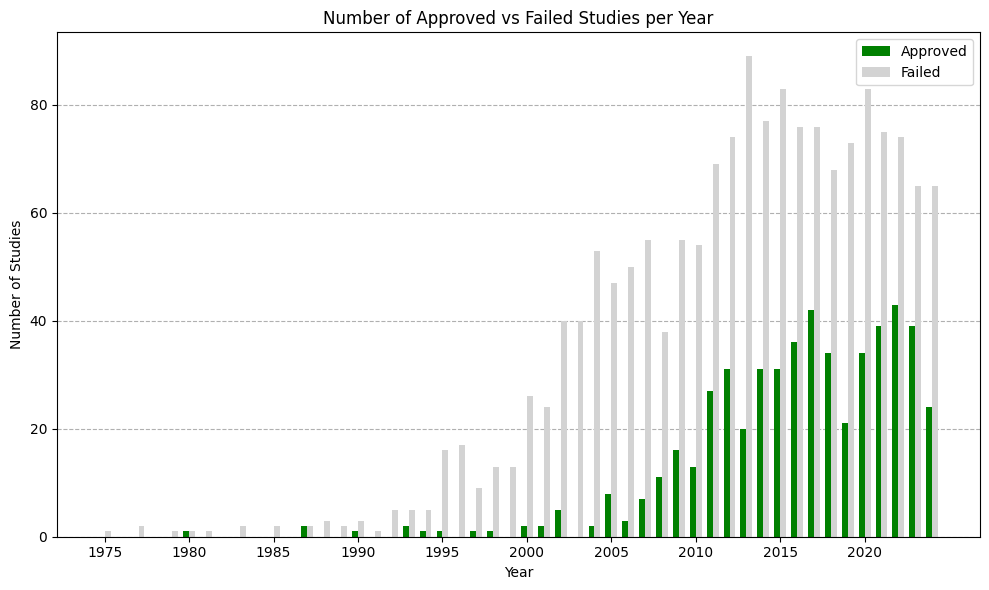

In [345]:
# Ensure 'year' is integer
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df_clean = df[(df['year'] != 2025) & (df['year'].notna())]

# Count studies per year per classification
counts = df_clean.groupby(['year', 'study_classification']).size().reset_index(name='count')

# Pivot to get approved and failed as columns
pivot_counts = counts.pivot(index='year', columns='study_classification', values='count').fillna(0)
pivot_counts = pivot_counts.sort_index()
years = pivot_counts.index.astype(int)
width = 0.35  # bar width

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(years - width/2, pivot_counts.get('approved', 0), width=width, label='Approved', color='green', zorder=2)
ax.bar(years + width/2, pivot_counts.get('failed', 0), width=width, label='Failed', color='lightgrey', zorder=2)

# Dashed grid behind bars
ax.grid(True, axis='y', linestyle='--', zorder=0)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Studies')
ax.set_title('Number of Approved vs Failed Studies per Year')

# Show only every 5th year on x-axis
ax.set_xticks([y for y in years if y % 5 == 0])
ax.set_xticklabels([y for y in years if y % 5 == 0])

ax.legend()
plt.tight_layout()
plt.show()

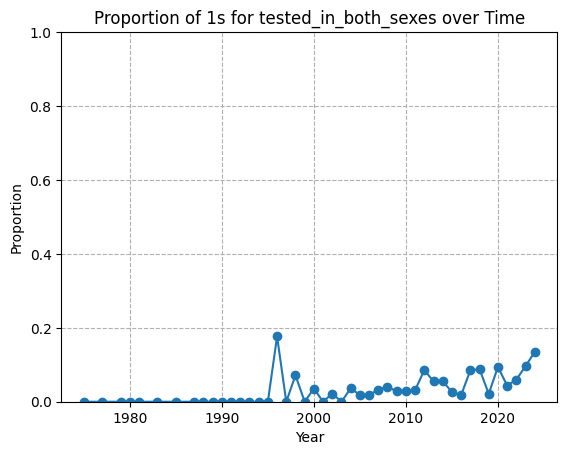

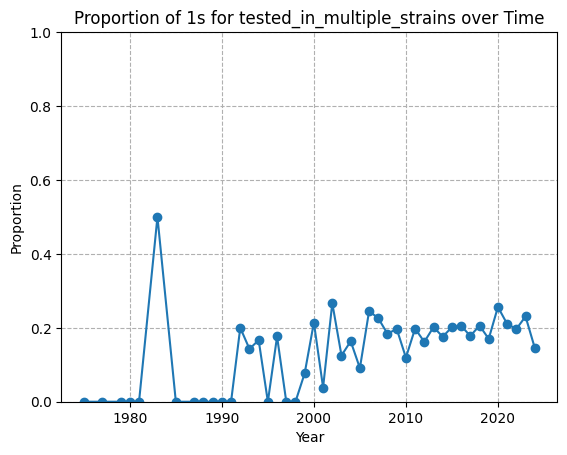

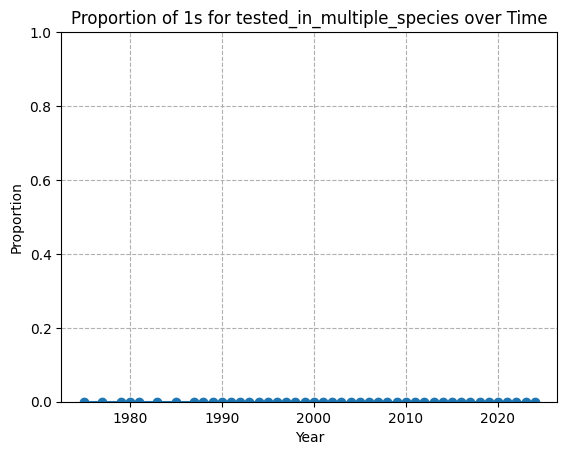

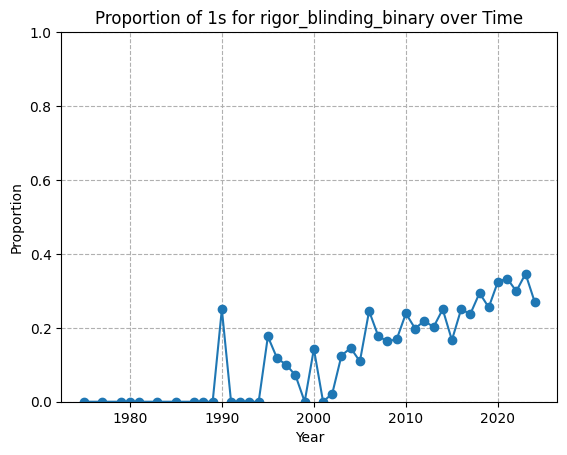

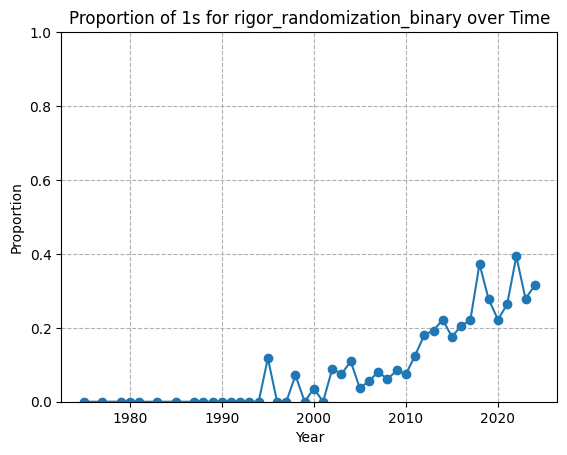

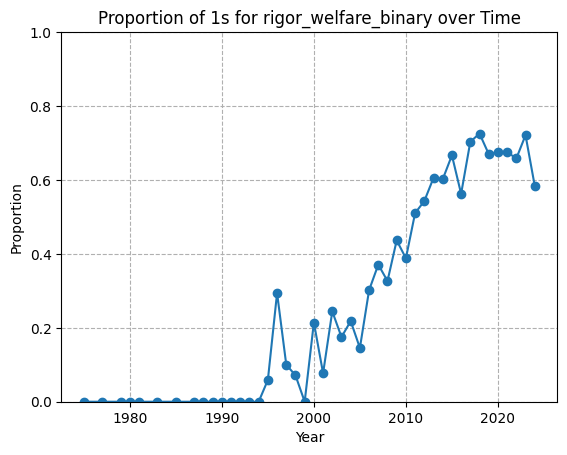

In [347]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Drop rows with missing year if any
df_clean = df.dropna(subset=['year'])
df_clean = df_clean[(df_clean['year'] != 2025) & (df_clean['year'].notna())]

# Group by year and calculate mean (proportion of 1s)
proportion_by_year = df_clean.groupby('year')[binary_cols].mean().reset_index()

for col in binary_cols:
    plt.figure()
    plt.plot(proportion_by_year['year'], proportion_by_year[col], marker='o')
    plt.title(f'Proportion of 1s for {col} over Time')
    plt.xlabel('Year')
    plt.ylabel('Proportion')
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--')
    plt.show()

In [349]:
def extract_unique_drugs(drug_series):
    all_drugs = []
    for entry in drug_series.dropna():
        drugs = [d.strip() for d in entry.split('|') if d.strip()]
        all_drugs.extend(drugs)
    return set(all_drugs)

# Separate approved and failed drug columns
approved_drugs = extract_unique_drugs(df[df['study_classification'] == 'approved']['drug'])
failed_drugs = extract_unique_drugs(df[df['study_classification'] == 'failed']['drug'])


In [357]:
len(approved_drugs), len(failed_drugs)

(589, 1753)

### flattened analysis

In [11]:
conditions_col_to_use = "disease"
drugs_col_to_use = "drug"
preclinical_df = preclinical_df_raw.copy()
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)

preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(drugs_col_to_use, ignore_index=True)

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_7726/433148696.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")


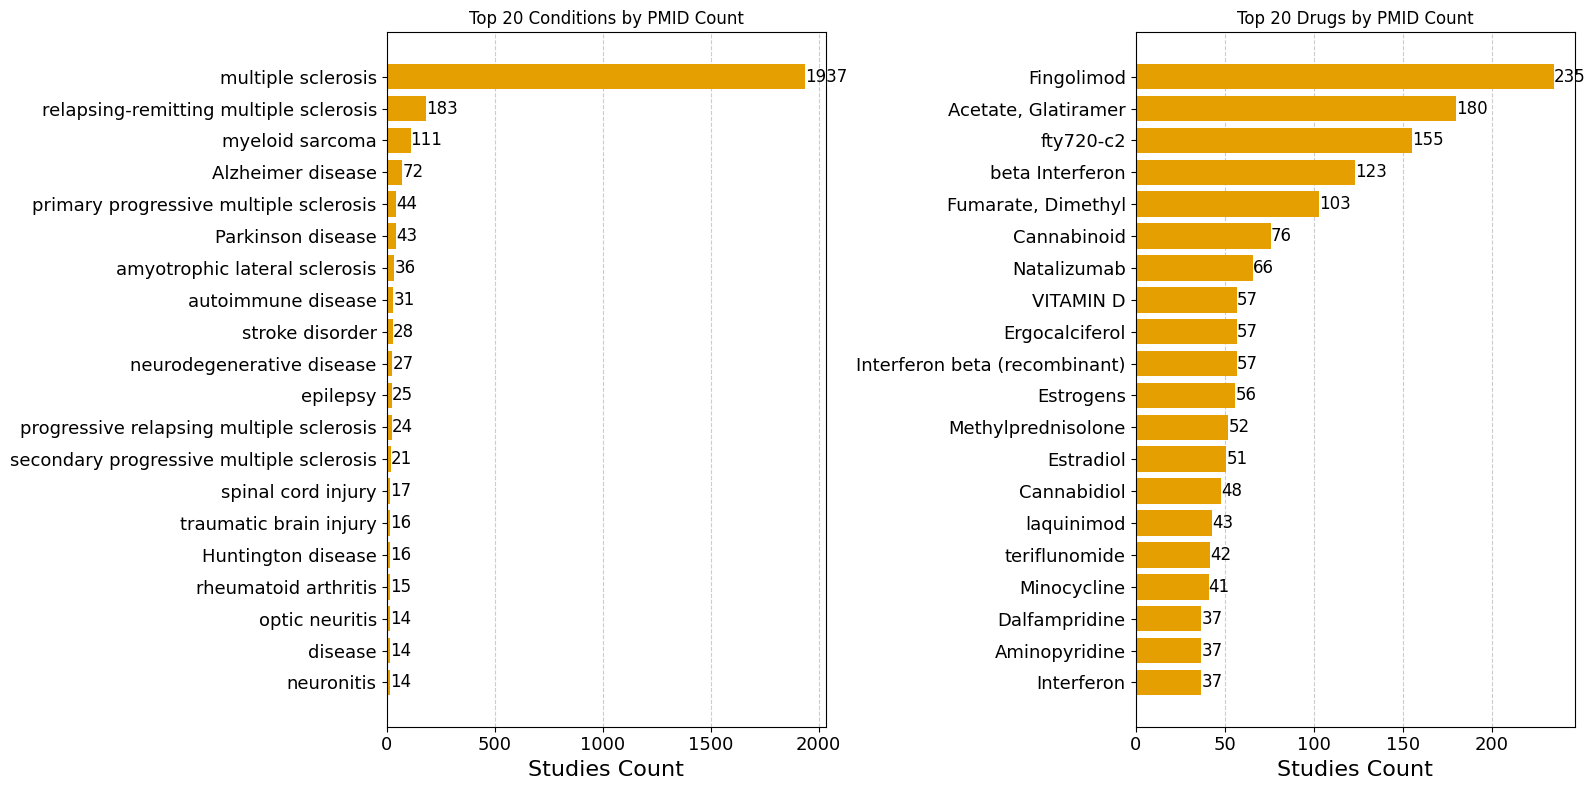

In [12]:
plot_top_entities_side_by_side(preclinical_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

In [19]:
preclinical_df.shape

(10420, 24)

In [21]:
preclinical_df[['PMID','drug','disease']].head()

,PMID,drug,disease
0,31738884,"Fumarate, Dimethyl",multiple sclerosis
1,31739156,Fingolimod,relapsing-remitting multiple sclerosis
2,31919372,3-methoxy -,multiple sclerosis
3,31919372,2cf34ap,multiple sclerosis
4,31919372,Dalfampridine,multiple sclerosis


In [23]:
# Successful (approved) DMTs
approved_dmts = [
    "Alemtuzumab",
    "Cladribine",
    "Dimethyl fumarate",
    "Fampridine",
    "Fingolimod",
    "Glatiramer acetate",
    "Interferon Beta 1",
    "Monomethyl fumarate",
    "Natalizumab",
    "Ocrelizumab",
    "Ofatumumab",
    "Ozanimod",
    "Peginterferon beta-1a",
    "Ponesimod",
    "Rituximab",
    "Siponimod",
    "Teriflunomide"
]


In [230]:
with open("approved_dmts_canonical.txt", "r") as f:
    approved_dmts_canonical = [line.strip() for line in f if line.strip()]

In [507]:
approved_dmts_canonical

['Alemtuzumab',
 'Cladribine',
 'Fumarate, Dimethyl',
 'Fampridine',
 'Fingolimod',
 'Acetate, Glatiramer',
 'beta 1 Interferon',
 'Monomethyl fumarate',
 'Natalizumab',
 'ocrelizumab',
 'ofatumumab',
 'ozanimod',
 'peginterferon beta-1a',
 'ponesimod',
 'riTUXimab',
 'siponimod',
 'teriflunomide']

In [509]:
len(approved_dmts_canonical)

17

In [40]:
from difflib import SequenceMatcher


In [47]:
def get_best_match(name, choices, threshold=0.7):
    best_score, best_choice = 0, None
    for choice in choices:
        score = SequenceMatcher(None, name.lower(), choice.lower()).ratio()
        if score > best_score:
            best_score, best_choice = score, choice
    return best_choice if best_score >= threshold else None

# — assume `df` is your full DataFrame with columns ["PMID","drug","disease"] —

# 1) Tag each row by whether its `drug` fuzzy-matches an approved DMT
preclinical_df['matched_approved'] = preclinical_df['drug'].apply(lambda d: get_best_match(d, approved_dmts_canonical))

# 2) Pull out all PMIDs that *do* have at least one approved match
approved_pmids = preclinical_df.loc[preclinical_df['matched_approved'].notnull(), 'PMID'].unique()

# 3) Build your two DataFrames
approved_df = preclinical_df[preclinical_df['PMID'].isin(approved_pmids)].copy()
failed_df   = preclinical_df[~preclinical_df['PMID'].isin(approved_pmids)].copy()

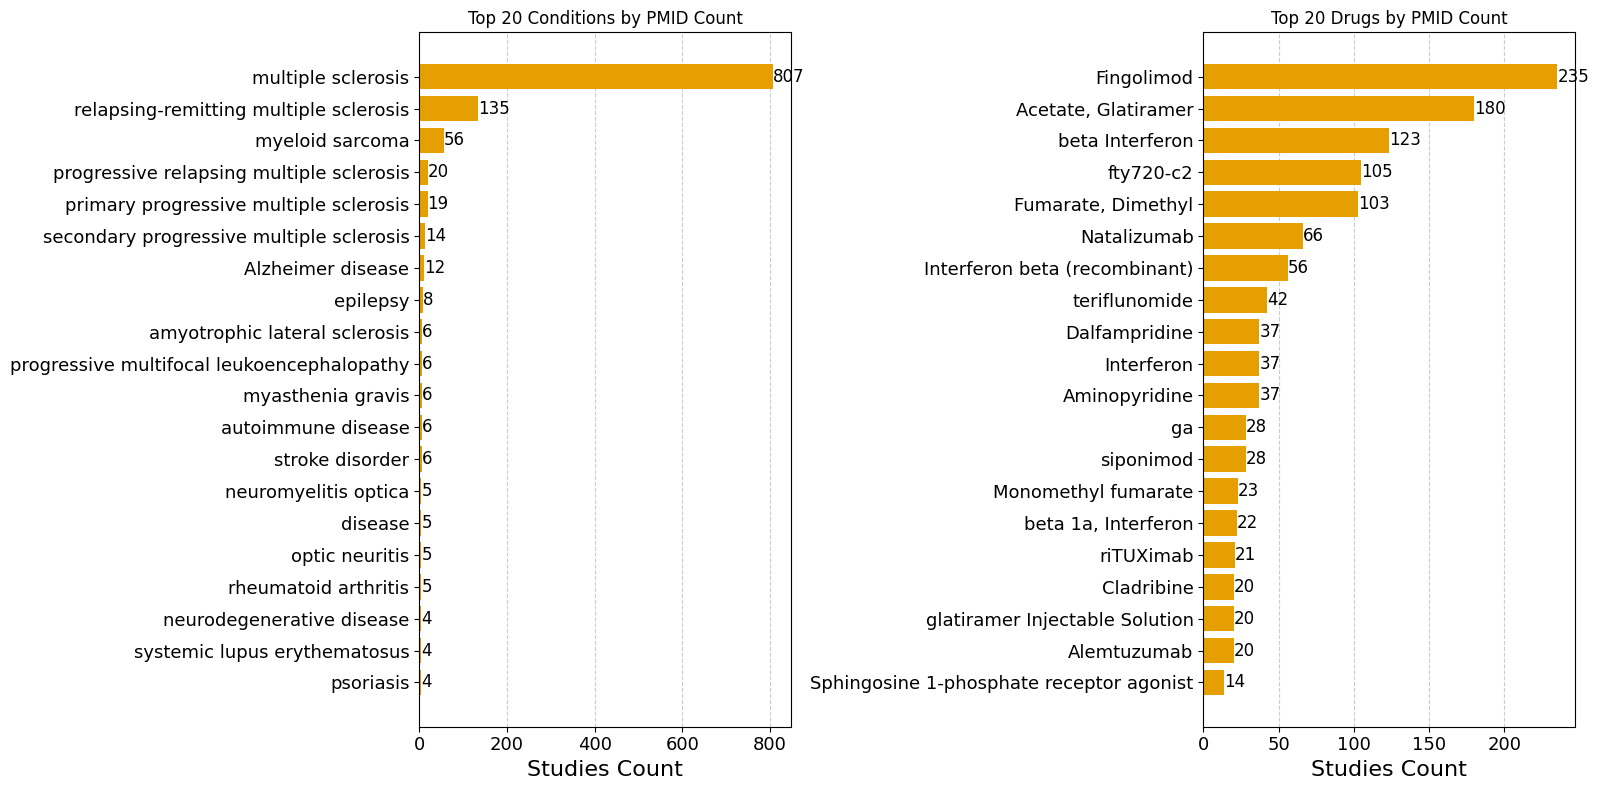

In [59]:
plot_top_entities_side_by_side(approved_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

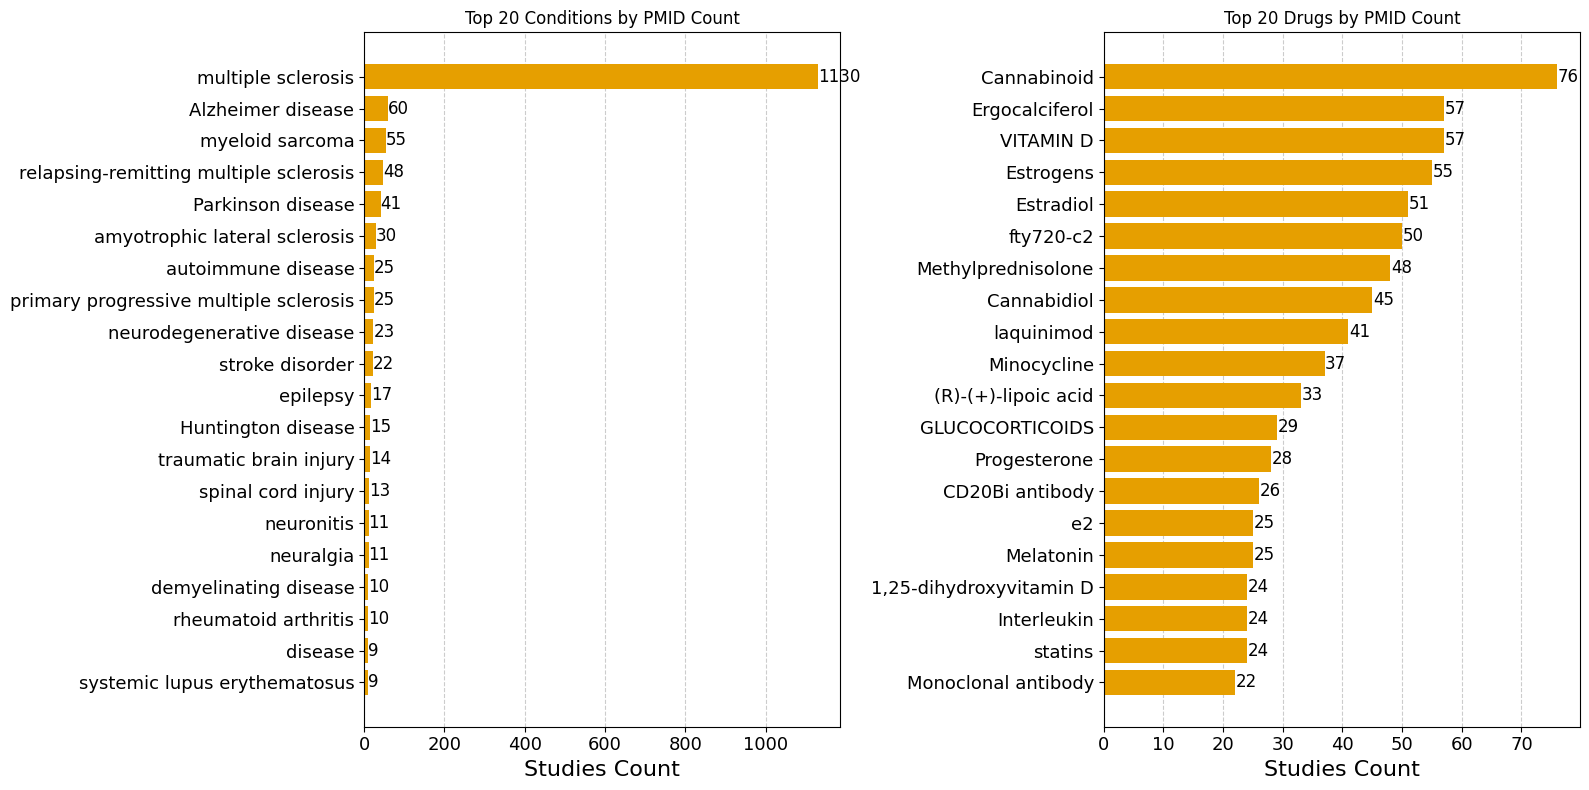

In [61]:
plot_top_entities_side_by_side(failed_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

In [87]:
import matplotlib.pyplot as plt

def plot_unique_pmid_counts(df, pmid_col, report_col):
    """
    Plots the count of unique PMIDs for each unique value in a specified report column,
    with percentage labels on top of the bars.

    Parameters:
    - df: pandas DataFrame containing the data.
    - pmid_col: name of the column with PMID identifiers.
    - report_col: name of the column whose unique values will be counted.

    Returns:
    - None: displays a bar chart.
    """
    # Calculate unique PMID counts per report value
    counts = df.groupby(report_col)[pmid_col].nunique()
    
    # Sort counts for better visualization
    counts = counts.sort_values(ascending=False)
    
    # Compute percentages
    total = counts.sum()
    percentages = (counts / total * 100).round(1)

    # Plot
    fig, ax = plt.subplots()
    bars = counts.plot(kind='bar', ax=ax)

    ax.set_xlabel(report_col)
    ax.set_ylabel(f'Unique {pmid_col} Count')
    ax.set_title(f'Unique {pmid_col} by {report_col}')
    plt.xticks(rotation=45, ha='right')

    # Annotate with percentages
    for i, (count, pct) in enumerate(zip(counts, percentages)):
        ax.text(i, count + total * 0.01, f'{pct}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


In [117]:
def plot_pmid_counts_over_year(
        df,
        pmid_col: str = "PMID",
        year_col: str = "year",
        *,
        dropna: bool = True,
        ax=None
    ):
    """
    Bar-plot the number of unique PMIDs observed in each publication year.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain `pmid_col` and `year_col`.
    pmid_col : str, default "PMID"
        Column holding PubMed IDs (or any identifier to count).
    year_col : str, default "year"
        Column holding publication year.
    dropna : bool, default True
        If True, rows whose year cannot be coerced to an int are removed.
        If False, those rows are kept with a nullable integer ('Int64') type.
    ax : matplotlib.axes.Axes, optional
        Supply an existing axis to add the plot to.

    Returns
    -------
    matplotlib.axes.Axes
        The axis with the rendered bar plot.
    """
    # Coerce year values to numeric first; anything unparseable → NaN
    year_series = pd.to_numeric(df[year_col], errors="coerce")

    if dropna:
        df = df.loc[year_series.notna()].copy()
        df[year_col] = year_series.dropna().astype(int)
    else:
        df = df.copy()
        df[year_col] = year_series.astype("Int64")   # pandas nullable integer

    # Aggregate: count *unique* PMIDs per year
    counts = (
        df.groupby(year_col, sort=True)[pmid_col]
          .nunique()          # or .size() if counting rows instead of unique IDs
    )

    # Plot
    if ax is None:
        _, ax = plt.subplots()
    counts.plot(kind="bar", ax=ax)       # simple, readable bar chart
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Unique PMID count")
    ax.set_title("PMID records per year")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()

    plt.show()
    

In [109]:
approved_df.columns

Index(['PMID', 'unique_conditions_linkbert_predictions_x',
       'unique_interventions_linkbert_predictions_x', 'year', 'journal_name',
       'publication_type', 'title', 'Unnamed: 0',
       'unique_conditions_linkbert_predictions_y',
       'unique_interventions_linkbert_predictions_y',
       'linkbert_mapped_conditions', 'linkbert_mapped_drugs', 'disease',
       'disease_mondo_termid', 'drug', 'drug_umls_termid', 'animal_sex',
       'animal_species', 'animal_age', 'rigor_blinding', 'rigor_randomization',
       'rigor_welfare', 'animal_strain', 'animal_number', 'matched_approved'],
      dtype='object')

In [217]:
approved_df.PMID.nunique(), failed_df.PMID.nunique()

(866, 1150)

In [233]:
hermes_included = pd.read_csv("../05_syst_reviews_validation/ms_berger_sr/HERMES_INCLUDED_PMIDs_valid_title.csv")
hermes_included.shape

(463, 3)

In [235]:
hermes_included.head()

,doi,pmid,title
0,10.3920/bm2016.0018,27633171,Enterococcus faecium strain L-3 and glatiramer...
1,10.3109/08820139.2013.825269,24063549,Synergistic effects of atorvastatin and all-tr...
2,10.1523/jneurosci.0398-18.2018,30185466,Reduced Microglial Activity and Enhanced Gluta...
3,10.1016/j.crimmu.2022.03.001,35496821,Loss of thymic function promotes EAE relapse i...
4,10.1016/j.expneurol.2013.08.002,23954214,Efficacy of vitamin D in treating multiple scl...


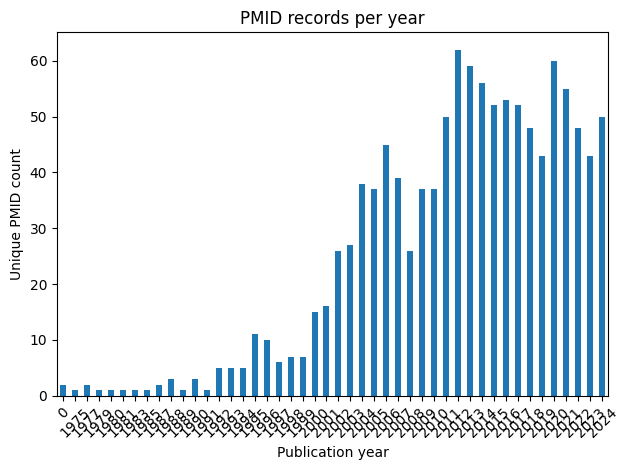

In [119]:
# Example usage:
plot_pmid_counts_over_year(failed_df, 'PMID', 'year')

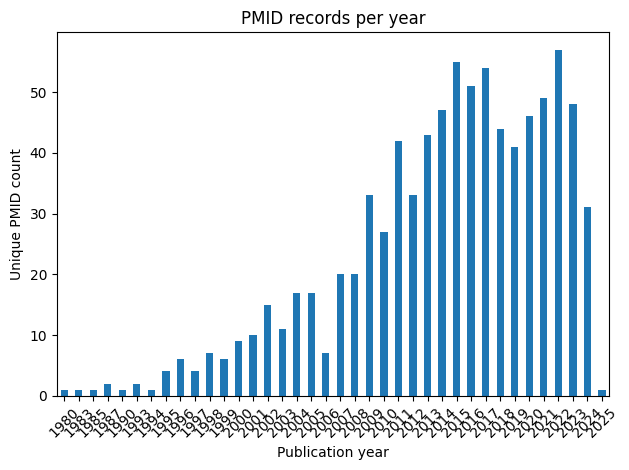

In [121]:
plot_pmid_counts_over_year(approved_df, 'PMID', 'year')

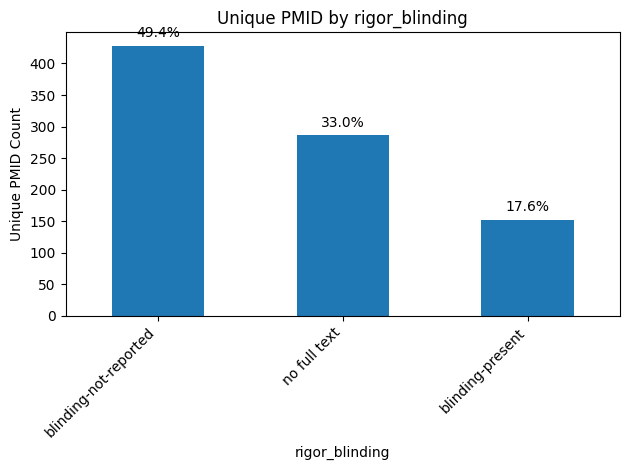

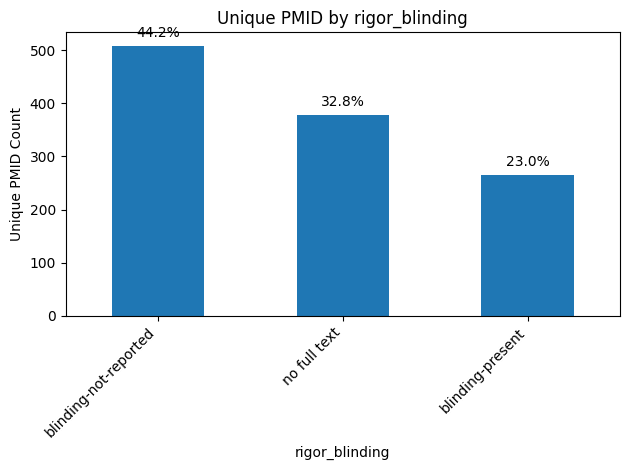

(None, None)

In [125]:
plot_unique_pmid_counts(approved_df, "PMID", "rigor_blinding"), plot_unique_pmid_counts(failed_df, "PMID", "rigor_blinding")

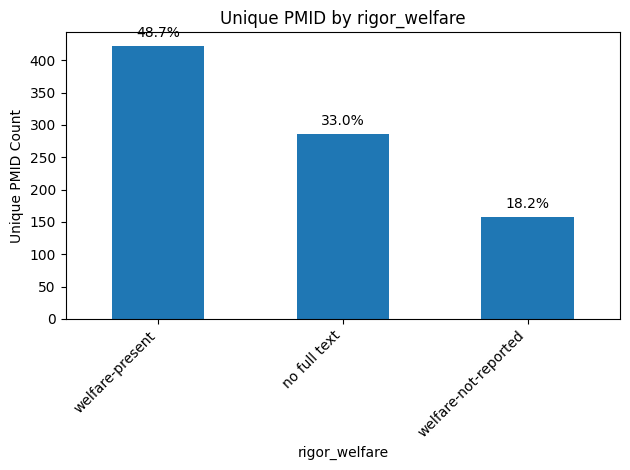

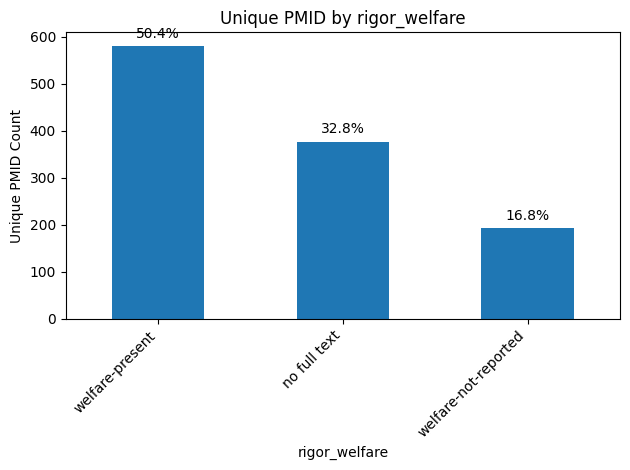

(None, None)

In [127]:
plot_unique_pmid_counts(approved_df, "PMID", "rigor_welfare"), plot_unique_pmid_counts(failed_df, "PMID", "rigor_welfare")

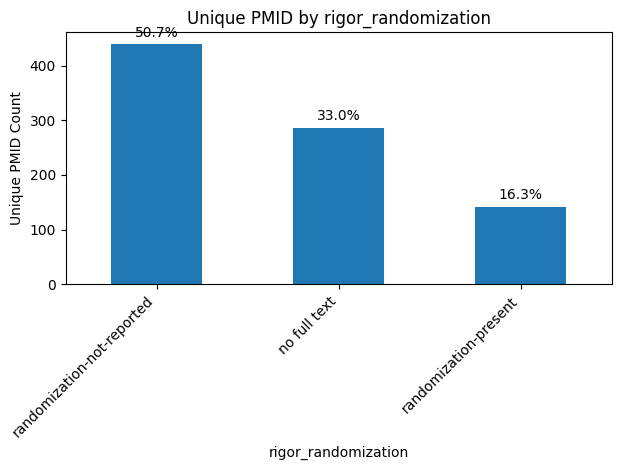

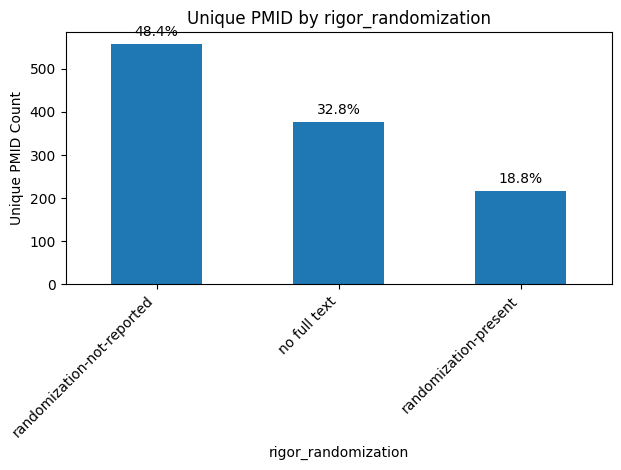

(None, None)

In [129]:
plot_unique_pmid_counts(approved_df, "PMID", "rigor_randomization"), plot_unique_pmid_counts(failed_df, "PMID", "rigor_randomization")

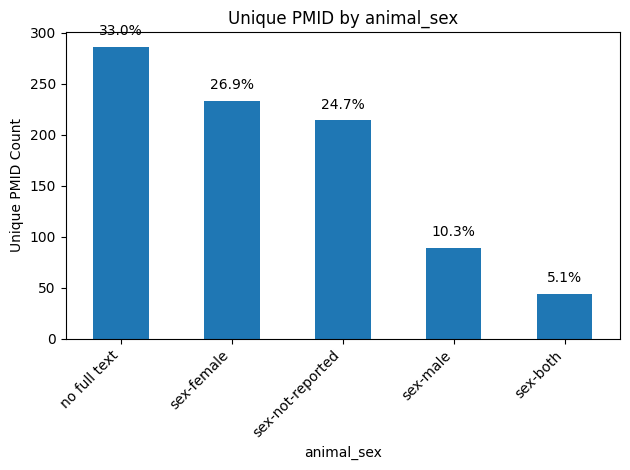

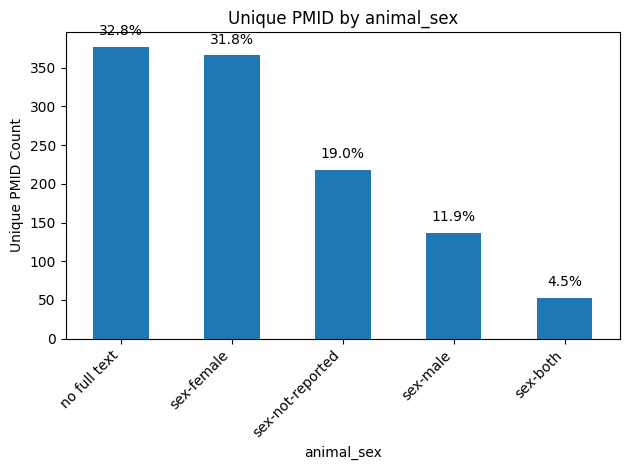

(None, None)

In [135]:
plot_unique_pmid_counts(approved_df, "PMID", "animal_sex"), plot_unique_pmid_counts(failed_df, "PMID", "animal_sex")

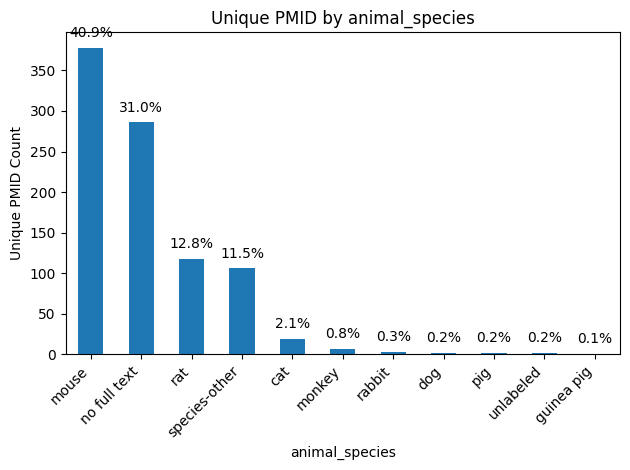

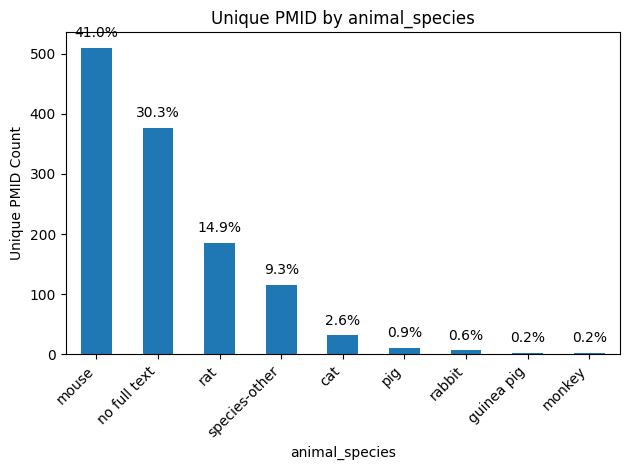

(None, None)

In [137]:
plot_unique_pmid_counts(approved_df, "PMID", "animal_species"), plot_unique_pmid_counts(failed_df, "PMID", "animal_species")

In [367]:
import requests
import pandas as pd

def first_fda_approval_details(drug):
    q = f'openfda.generic_name:"{drug}"'
    try:
        resp = requests.get(
            "https://api.fda.gov/drug/drugsfda.json",
            params={"search": q, "limit": 100}
        )
        resp.raise_for_status()
    except requests.HTTPError as e:
        if resp.status_code == 404:
            return None
        else:
            raise

    records = resp.json().get("results", [])

    orig_subs = []
    for rec in records:
        for sub in rec.get("submissions", []):
            if sub.get("submission_type") in ("ORIG", "NDA", "BLA"):
                date = pd.to_datetime(sub["submission_status_date"],
                                      format="%Y%m%d",
                                      errors="coerce")
                if pd.notna(date):
                    orig_subs.append({
                        "date": date,
                        "submission": sub,
                        "record": rec
                    })

    if not orig_subs:
        return None

    first = min(orig_subs, key=lambda x: x["date"])
    sub = first["submission"]
    rec = first["record"]
    openfda = rec.get("openfda", {})

    return {
        "generic_name": drug,
        "sponsor_name": rec.get("sponsor_name"),
        "application_number": rec.get("application_number"),
        "submission_type": sub.get("submission_type"),
        "submission_number": sub.get("submission_number"),
        "approval_date": first["date"],
        "indication": rec.get("products", [{}])[0].get("indication"),
        "pharm_class_cs": openfda.get("pharm_class_cs"),
        "pharm_class_epc": openfda.get("pharm_class_epc"),
        "pharm_class_pe": openfda.get("pharm_class_pe"),
        "pharm_class_moa": openfda.get("pharm_class_moa")
    }


In [369]:
details = first_fda_approval_details("FILGRASTIM-TXID")
print(details)

{'generic_name': 'FILGRASTIM-TXID', 'sponsor_name': 'TANVEX BIOPHARMA USA INC', 'application_number': 'BLA761126', 'submission_type': 'ORIG', 'submission_number': '1', 'approval_date': Timestamp('2024-06-28 00:00:00'), 'indication': None, 'pharm_class_cs': ['Granulocyte Colony-Stimulating Factor [CS]'], 'pharm_class_epc': ['Leukocyte Growth Factor [EPC]'], 'pharm_class_pe': ['Increased Myeloid Cell Production [PE]'], 'pharm_class_moa': None}


In [370]:
approved_dmts_canonical, approved_dmts

(['Alemtuzumab',
  'Cladribine',
  'Fumarate, Dimethyl',
  'Fampridine',
  'Fingolimod',
  'Acetate, Glatiramer',
  'beta 1 Interferon',
  'Monomethyl fumarate',
  'Natalizumab',
  'ocrelizumab',
  'ofatumumab',
  'ozanimod',
  'peginterferon beta-1a',
  'ponesimod',
  'riTUXimab',
  'siponimod',
  'teriflunomide'],
 ['Alemtuzumab',
  'Cladribine',
  'Dimethyl fumarate',
  'Fampridine',
  'Fingolimod',
  'Glatiramer acetate',
  'Interferon Beta 1',
  'Monomethyl fumarate',
  'Natalizumab',
  'Ocrelizumab',
  'Ofatumumab',
  'Ozanimod',
  'Peginterferon beta-1a',
  'Ponesimod',
  'Rituximab',
  'Siponimod',
  'Teriflunomide'])

In [373]:
drug_years = {}
pharm_class_epc = {}
pharm_class_moa = {}

for drug, canonical_drug_name in zip(approved_dmts, approved_dmts_canonical):
    details = first_fda_approval_details(drug)
    if details and details.get("approval_date") is not None:
        drug_years[canonical_drug_name] = details["approval_date"].year
    if details and details.get("pharm_class_epc") is not None:
        pharm_class_epc[canonical_drug_name] = details["pharm_class_epc"]
    if details and details.get("pharm_class_moa") is not None:
        pharm_class_moa[canonical_drug_name] = details["pharm_class_moa"]
    else:
        drug_years[canonical_drug_name] = None
        pharm_class_epc[canonical_drug_name] = None
        pharm_class_moa[canonical_drug_name] = None

print(drug_years)

{'Alemtuzumab': 2001, 'Cladribine': None, 'Fumarate, Dimethyl': None, 'Fampridine': None, 'Fingolimod': None, 'Acetate, Glatiramer': None, 'beta 1 Interferon': None, 'Monomethyl fumarate': None, 'Natalizumab': 2004, 'ocrelizumab': 2017, 'ofatumumab': 2009, 'ozanimod': None, 'peginterferon beta-1a': None, 'ponesimod': 2021, 'riTUXimab': 1997, 'siponimod': None, 'teriflunomide': 2012}


In [433]:
USER_AGENT = (
    "Mozilla/5.0 (compatible; FDAYearScraper/1.0; +your-email-or-repo)"
)

# ----------------------------------------------------------------------
# Low-level page fetcher  →  integer year | None
# ----------------------------------------------------------------------
def _year_from_history_page(slug: str, session: requests.Session) -> int | None:
    """
    Try https://www.drugs.com/history/<slug>.html and pull 'First approved <YEAR>'
    Returns the int YEAR or None if not found / 404 / parse fail.
    """
    url = f"https://www.drugs.com/history/{slug}.html"
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=(5, 15))
        if r.status_code == 404:           # saves a soup parse if the page is absent
            return None
        r.raise_for_status()
    except requests.RequestException:
        return None                        # network error, SSL issue, etc.

    soup = BeautifulSoup(r.text, "html.parser")
    node = soup.find(string=re.compile(r"First approved", re.I))
    if not node:
        return None

    m = re.search(r"\b(\d{4})\b", node)
    return int(m.group(1)) if m else None


# ----------------------------------------------------------------------
# Heuristic slug generator  (very lightweight “slugify”)
# e.g. "Fumarate, Dimethyl" → ["fumarate-dimethyl", "dimethyl-fumarate"]
# ----------------------------------------------------------------------
def _candidate_slugs(drug_name: str) -> list[str]:
    # basic alnum-only “words”
    words = re.sub(r"[^0-9a-zA-Z]+", " ", drug_name).lower().split()
    slugs = ["-".join(words)]

    # if original name had a comma, also try reversed word order
    if "," in drug_name:
        slugs.append("-".join(reversed(words)))

    # de-duplicate while preserving order
    return list(dict.fromkeys(slugs))


# ----------------------------------------------------------------------
# Public helper
# ----------------------------------------------------------------------
def fill_missing_approval_years(data: dict[str, int | None],
                                delay: float = 1.0) -> dict[str, int | None]:
    """
    Mutates and returns `data`, filling any None entries with the scraped year
    (or leaving None if the page/year is not found).
    `delay` pauses N seconds between hits to be polite.
    """
    session = requests.Session()

    for drug, yr in data.items():
        if yr is not None:
            continue                      # already have a year

        for slug in _candidate_slugs(drug):
            got = _year_from_history_page(slug, session)
            if got:
                data[drug] = got
                break                     # stop trying other slugs

        time.sleep(delay)                 # throttle

    return data

fill_missing_approval_years(drug_years)


{'Alemtuzumab': 2001,
 'Cladribine': 2019,
 'Fumarate, Dimethyl': 2013,
 'Fampridine': None,
 'Fingolimod': 2010,
 'Acetate, Glatiramer': None,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': 2020,
 'Natalizumab': 2004,
 'ocrelizumab': 2017,
 'ofatumumab': 2009,
 'ozanimod': 2020,
 'peginterferon beta-1a': 2014,
 'ponesimod': 2021,
 'riTUXimab': 1997,
 'siponimod': 2019,
 'teriflunomide': 2012}

In [281]:
pharm_class_moa

{'Alemtuzumab': ['CD52-directed Antibody Interactions [MoA]'],
 'Cladribine': None,
 'Fumarate, Dimethyl': None,
 'Fampridine': None,
 'Fingolimod': None,
 'Acetate, Glatiramer': None,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': None,
 'Natalizumab': ['Integrin Receptor Antagonists [MoA]'],
 'ocrelizumab': ['CD20-directed Antibody Interactions [MoA]'],
 'ofatumumab': ['CD20-directed Antibody Interactions [MoA]'],
 'ozanimod': None,
 'peginterferon beta-1a': None,
 'ponesimod': ['Sphingosine 1-Phosphate Receptor Modulators [MoA]'],
 'riTUXimab': ['CD20-directed Antibody Interactions [MoA]'],
 'siponimod': ['Sphingosine 1-Phosphate Receptor Modulators [MoA]'],
 'teriflunomide': ['Dihydroorotate Dehydrogenase Inhibitors [MoA]']}

In [278]:
pharm_class_epc

{'Alemtuzumab': ['CD52-directed Cytolytic Antibody [EPC]'],
 'Cladribine': ['Purine Antimetabolite [EPC]'],
 'Fumarate, Dimethyl': None,
 'Fampridine': None,
 'Fingolimod': None,
 'Acetate, Glatiramer': None,
 'beta 1 Interferon': None,
 'Monomethyl fumarate': None,
 'Natalizumab': ['Integrin Receptor Antagonist [EPC]'],
 'ocrelizumab': ['CD20-directed Cytolytic Antibody [EPC]'],
 'ofatumumab': ['CD20-directed Cytolytic Antibody [EPC]'],
 'ozanimod': None,
 'peginterferon beta-1a': ['Interferon beta [EPC]'],
 'ponesimod': ['Sphingosine 1-phosphate Receptor Modulator [EPC]'],
 'riTUXimab': ['CD20-directed Cytolytic Antibody [EPC]'],
 'siponimod': ['Sphingosine 1-phosphate Receptor Modulator [EPC]'],
 'teriflunomide': ['Pyrimidine Synthesis Inhibitor [EPC]']}

In [179]:
approved_df[['PMID','drug','year']]

,PMID,drug,year
0,31738884,"Fumarate, Dimethyl",2020.0
1,31739156,Fingolimod,2020.0
2,31919372,3-methoxy -,2020.0
3,31919372,2cf34ap,2020.0
4,31919372,Dalfampridine,2020.0
...,...,...,...
10413,33102475,Fingolimod,2020.0
10414,33102475,Sphingosine 1-phosphate receptor agonist,2020.0
10415,33102475,fty,2020.0
10416,33106366,Alemtuzumab,2021.0


In [487]:
import matplotlib.ticker as ticker       # add this with the other imports

# --- fuzzy match helper -------------------------------------------------
def fuzzy_filter(df, target, threshold=0.7):
    """Return rows whose 'drug' name is ≥ `threshold` similar to `target`."""
    def sim(a, b): return SequenceMatcher(None, a.lower(), b.lower()).ratio()
    return df[df["drug"].apply(lambda x: sim(x, target) >= threshold)].copy()

# --- main plotting helper ----------------------------------------------
def plot_drug_studies(drug, approval_year, df,
                      threshold=0.7, *, bubble=True, scale=40):
    """
    • bubble=True  → one bubble per YEAR, size ∝ #studies,
      with the count printed in its centre.
    • bubble=False → individual dots stacked vertically.
    """
    studies = fuzzy_filter(df, drug, threshold)
    if studies.empty:
        print(f"No studies found for '{drug}'."); return

    counts = (
        studies.groupby("year")["PMID"]
        .nunique()
        .reset_index(name="n")
    )

    plt.figure(figsize=(10, 2.8))

    if bubble:
        sizes = counts["n"] * scale
        plt.scatter(counts["year"], [0]*len(counts), s=sizes, alpha=.7)
        for yr, n in counts.itertuples(index=False):
            plt.text(yr, 0, n, ha="center", va="center", zorder=3, fontsize=8)
    else:
        xs, ys = [], []
        for yr, n in counts.itertuples(index=False):
            xs.extend([yr]*n)
            ys.extend(range(n))
        plt.scatter(xs, ys, alpha=.7)
        plt.yticks([])

    # approval marker
    plt.axvline(x=approval_year, linestyle="--")
    plt.scatter([approval_year], [0], marker="D")

    # integer x-axis
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.title(f"{drug} – studies by year (approval {approval_year})")
    plt.xlabel("Publication year")
    plt.yticks([])
    plt.tight_layout()
    plt.show()

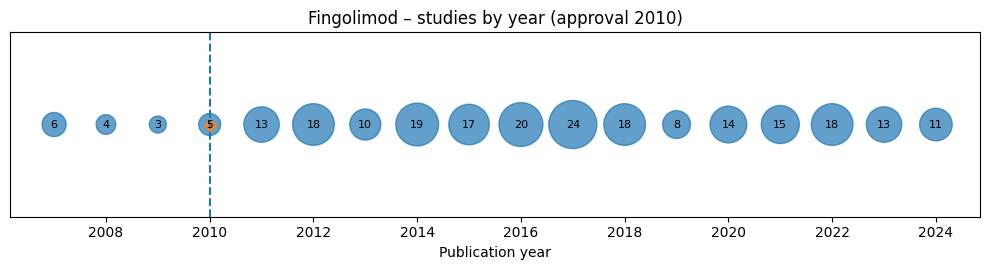

In [489]:
plot_drug_studies("Fingolimod",
                  drug_years["Fingolimod"],
                  approved_df,
                  bubble=True,   # or False
                  scale=50)      # tweak bubble sizes if you like

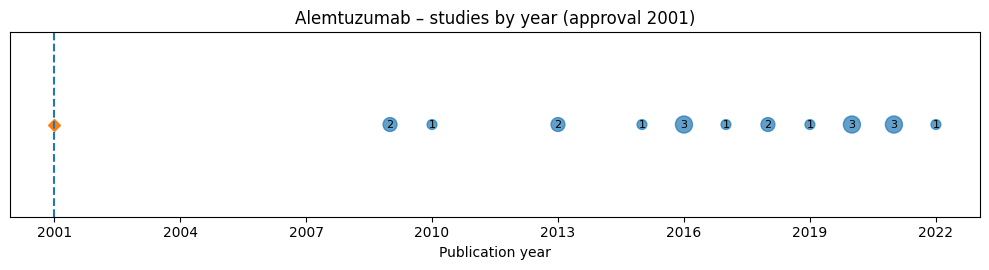

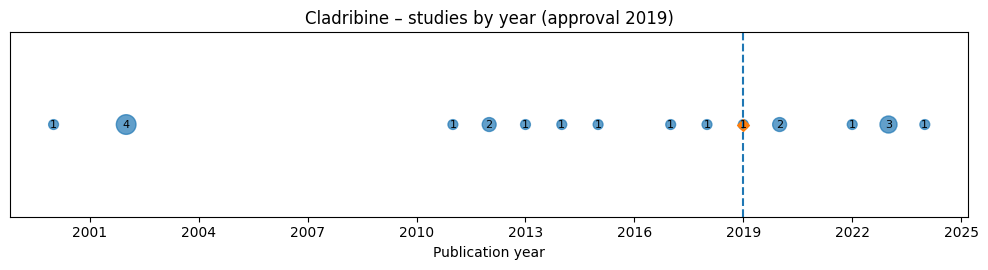

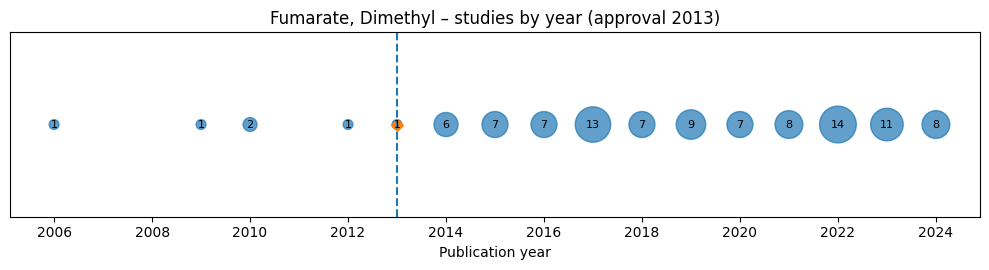

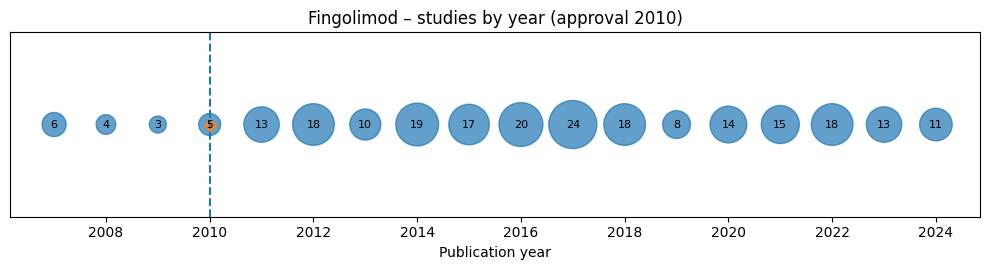

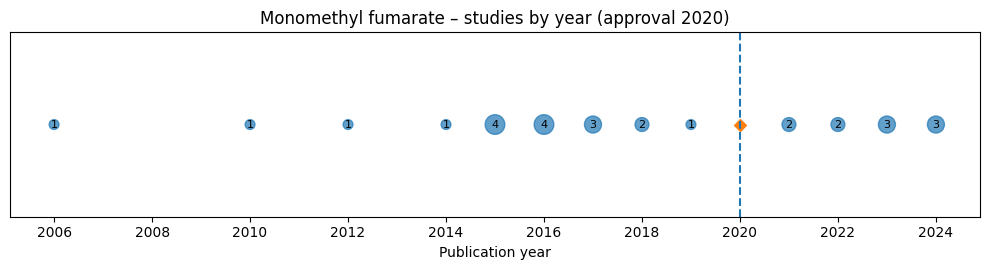

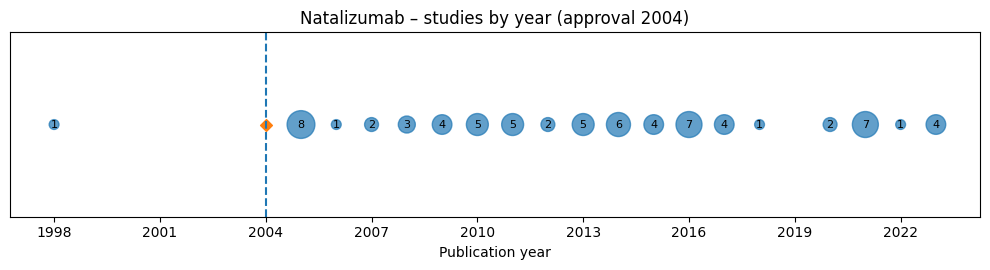

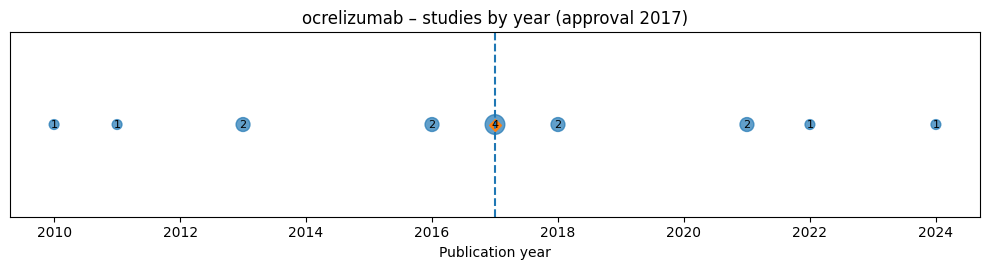

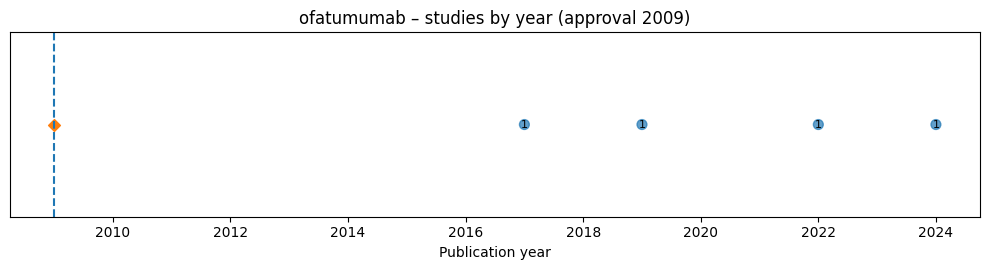

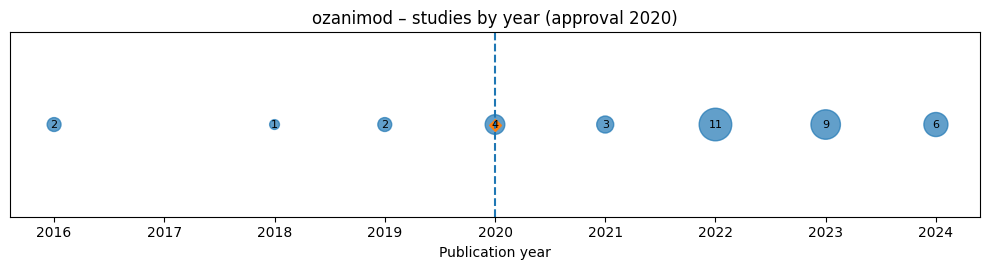

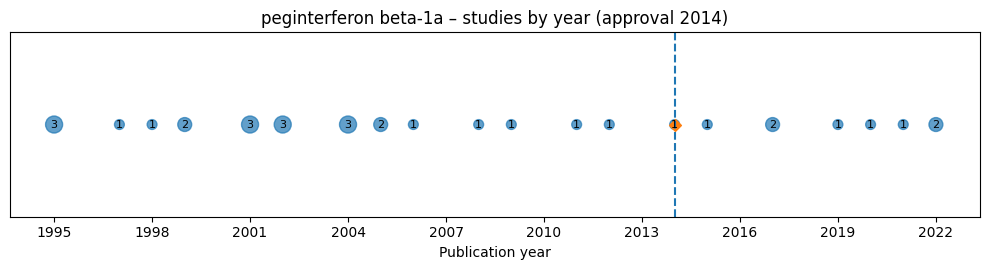

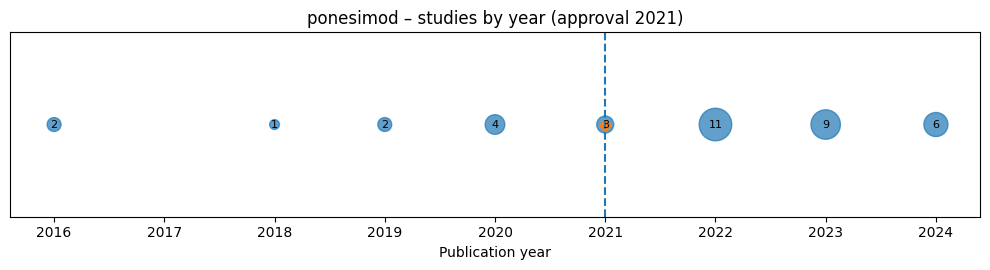

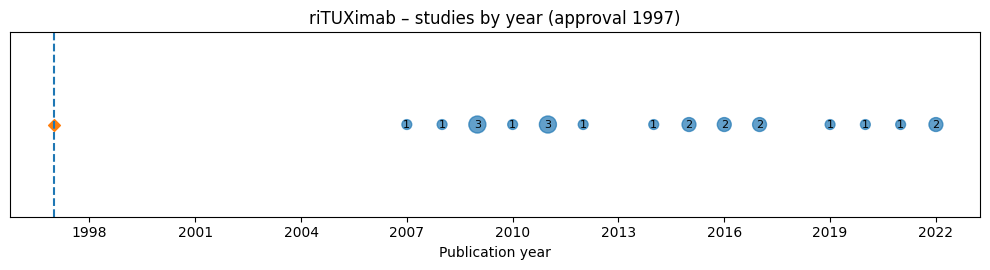

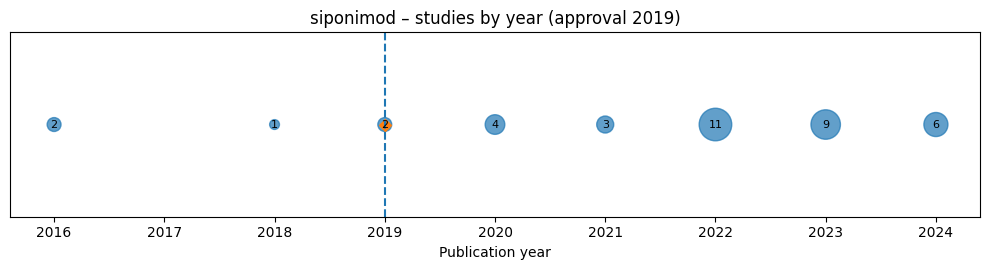

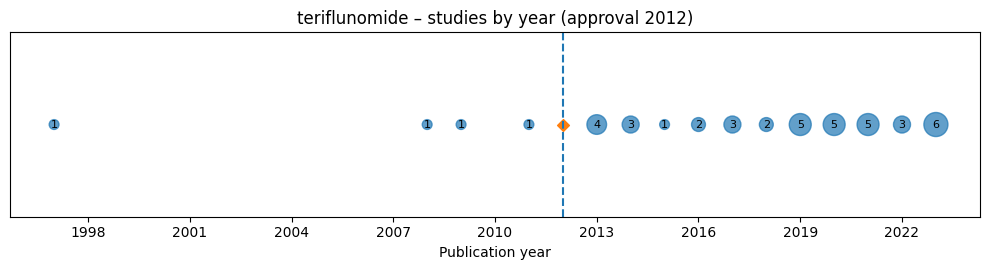

In [491]:
for drug, appr_year in drug_years.items():
    if appr_year is None:
        continue
    plot_drug_studies(drug, appr_year, approved_df, bubble=True, scale=50)

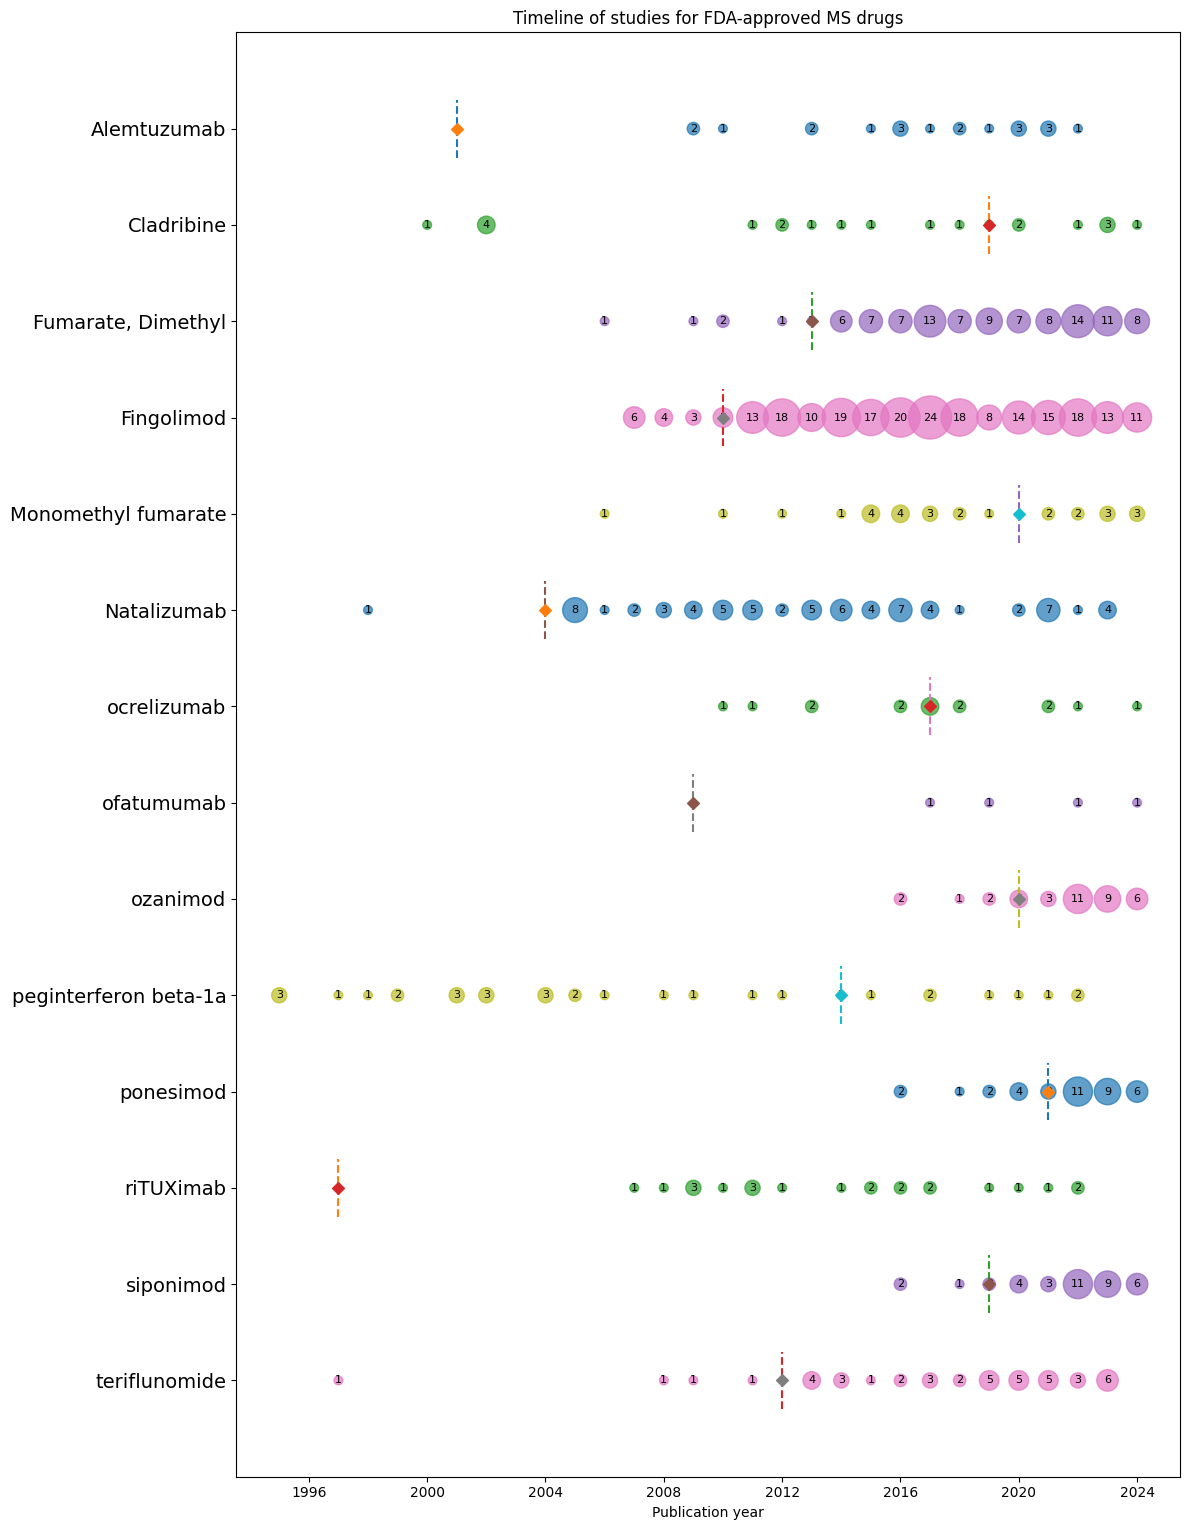

In [505]:
# ------------------------------------------------------------------
# build one compact bubble chart for *all* drugs
# ------------------------------------------------------------------
drugs_in_order = [d for d, y in drug_years.items() if y is not None]
n_drugs        = len(drugs_in_order)
if n_drugs == 0:
    raise ValueError("No drugs with approval year found in `drug_years`.")

fig_height = 1.1 * n_drugs
plt.figure(figsize=(12, fig_height))

scale = 40     # bubble size multiplier

for i, drug in enumerate(drugs_in_order):
    y_pos       = n_drugs - 1 - i          # top-to-bottom ordering
    appr_year   = drug_years[drug]
    studies     = fuzzy_filter(approved_df, drug, threshold=0.7)
    if studies.empty:
        # skip completely empty: still reserve a y slot so labels align
        continue

    counts = (
        studies.groupby("year")["PMID"]
        .nunique()
        .reset_index(name="n")
        .sort_values("year")
    )

    # bubbles
    plt.scatter(
        counts["year"],
        [y_pos] * len(counts),
        s=counts["n"] * scale,
        alpha=0.7,
    )

    # label each bubble with the number of studies
    for yr, n in counts.itertuples(index=False):
        plt.text(yr, y_pos, n, ha="center", va="center", fontsize=8, zorder=3)

    # approval-year marker (short vertical line + diamond)
    plt.plot([appr_year, appr_year], [y_pos - 0.3, y_pos + 0.3], linestyle="--")
    plt.scatter([appr_year], [y_pos], marker="D", zorder=4)

# --- axes cosmetics -----------------------------------------------------
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_yticks(range(n_drugs))
ax.set_yticklabels(reversed(drugs_in_order), fontsize=14)   # align with y_pos calculation
ax.set_ylim(-1, n_drugs)
plt.xlabel("Publication year")
plt.title("Timeline of studies for FDA-approved MS drugs")
plt.tight_layout()
plt.show()

In [437]:
# Define the fuzzy filter function
def fuzzy_filter(df, target, threshold=0.7):
    """
    Returns rows where the 'drug' column has a similarity ratio >= threshold with the target string.
    """
    def similarity(a, b):
        return SequenceMatcher(None, a, b).ratio()
    
    mask = df['drug'].apply(lambda x: similarity(x, target) >= threshold)
    return df[mask]

# Build summary using fuzzy matching
summary = []
for drug, appr_year in drug_years.items():
    if appr_year is None:
        continue
    df_sub = fuzzy_filter(approved_df, drug, threshold=0.7)
    total = df_sub['PMID'].nunique()
    before = df_sub[df_sub['year'] <= appr_year]['PMID'].nunique()
    after = df_sub[df_sub['year'] > appr_year]['PMID'].nunique()
    summary.append({
        'drug': drug,
        'approval_year': appr_year,
        'total_unique_pmids': total,
        'before_unique': before,
        'after_unique': after
    })
summary_df = pd.DataFrame(summary)

In [438]:
summary_df

,drug,approval_year,total_unique_pmids,before_unique,after_unique
0,Alemtuzumab,2001,20,0,20
1,Cladribine,2019,20,13,6
2,"Fumarate, Dimethyl",2013,103,6,97
3,Fingolimod,2010,235,17,218
4,Monomethyl fumarate,2020,28,18,10
5,Natalizumab,2004,72,1,71
6,ocrelizumab,2017,16,10,6
7,ofatumumab,2009,4,0,4
8,ozanimod,2020,38,9,29
9,peginterferon beta-1a,2014,22,16,6


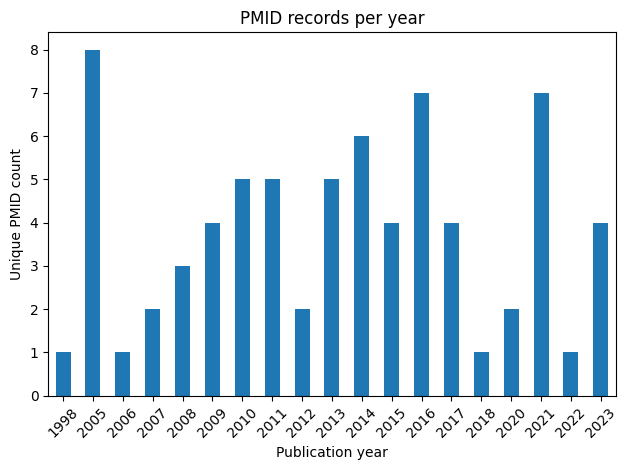

In [213]:
plot_pmid_counts_over_year(fuzzy_filter(approved_df, "Natalizumab", threshold=0.7), 'PMID', 'year')